# Assignment 1: Sanskrit-English Sentence Embeddings
## AIL7390 — Deep Learning for NLP

**Objective:** Generate low-dimensional, semantically meaningful sentence embeddings for parallel Sanskrit-English text.

**Scoring:** `Score = 0.4 × MarksDim + 0.6 × MarksCosine`

> **Runtime:** Google Colab GPU (L4)

---

<!-- ### Notebook Structure

| # | Section | Purpose |
|---|---------|---------|
| 0 | Setup & Installation | Mount Drive, install deps, config |
| 1 | Data Loading & Preprocessing | Load, align, clean data |
| 2 | Utilities | Encoding, sklearn eval, InfoNCE loss |
| 3 | Baselines | Random, Sanganaka ZS, Qwen ZS, Jina ZS |
| 4 | Fine-Tune Sanganaka + Curves | Track A: Sanskrit specialist |
| 5 | Fine-Tune Qwen + Curves | Track B: Compact multilingual |
| 5B | Fine-Tune Jina v5 + Curves | Track C: SOTA compact (best model) |
| 6 | Projection Ablations + Curves | Sanganaka→32/64/128, Qwen 128→32 |
| 8 | Full Dev + Test Evaluation | All models, sklearn cosine, comparison table |
| 9 | t-SNE Visualization | 100 test pairs (required for report) |
| 10 | Example Analysis | 5–10 best/worst pairs (required for report) |
| 11 | Report Plots | Cosine distribution, dimension vs cosine, rubric bar chart |
| 12 | Final Submission Export | .npy files |
| 13 | Inference on New Test Data | Load new CSVs, encode, evaluate, save .npy | -->

### Pre-trained Models Used
- `sanganaka/bge-m3-sanskritFT` — BGE-M3 fine-tuned on Sanskrit (1024-d)
- `Qwen/Qwen3-Embedding-0.6B` — Multilingual embedding model (configurable dim)
- `jinaai/jina-embeddings-v5-text-small` — SOTA multilingual embedding (Feb 2026, Matryoshka 32–1024)


## 0. Setup & Installation

In [ ]:
# 0.1  Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = "/content/drive/MyDrive/AIL7390_Assignment1"
os.makedirs(PROJECT_ROOT, exist_ok=True)
os.makedirs(f"{PROJECT_ROOT}/models", exist_ok=True)
os.makedirs(f"{PROJECT_ROOT}/outputs", exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")


Mounted at /content/drive
Project root: /content/drive/MyDrive/AIL7390_Assignment1


In [ ]:
 
# 0.2  Install Dependencies

!pip install -q transformers sentence-transformers accelerate


In [ ]:

# 0.3  Data Setup

# Put your 6 CSVs in Google Drive at the path below,

DATA_DIR = f"{PROJECT_ROOT}/data"
os.makedirs(DATA_DIR, exist_ok=True)


csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]
print(f"CSV files found: {sorted(csv_files)}")
assert len(csv_files) >= 6, "Upload all 6 CSV files (train/dev/test x en/sa)"


CSV files found: ['dev_en_1000.csv', 'dev_sa_1000.csv', 'test_en_1000.csv', 'test_sa_1000.csv', 'train_en_10000.csv', 'train_sa_10000.csv']


In [ ]:
# 0.4  Imports
import os, re, csv, json, warnings, random, copy, gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoModel, AutoTokenizer
from sklearn.metrics.pairwise import cosine_similarity as sklearn_cosine_similarity
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 6)})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")



Device : cuda
GPU    : NVIDIA L4
VRAM   : 23.7 GB


In [ ]:
# 0.5  Configuration

CFG = {
    "data_dir": DATA_DIR,
    "output_dir": f"{PROJECT_ROOT}/outputs",
    "model_dir": f"{PROJECT_ROOT}/models",

    "sanganaka_name": "sanganaka/bge-m3-sanskritFT",
    "qwen_name": "Qwen/Qwen3-Embedding-0.6B",
    "jina_name": "jinaai/jina-embeddings-v5-text-small",

    # Training — adjust batch_size for your GPU
    # T4 (15GB): batch_size=8, grad_accum=8
    # L4 (24GB): batch_size=16, grad_accum=4
    # A100 (40GB+): batch_size=32, grad_accum=2
    "batch_size": 16,
    "lr": 2e-5,
    "epochs": 5,
    "warmup_ratio": 0.1,
    "temperature": 0.05,
    "max_seq_len": 128,
    "grad_accum_steps": 4,

    # Projection
    "proj_lr": 1e-3,
    "proj_epochs": 10,
    "proj_batch_size": 256,



    "qwen_dims": [32, 64, 128],
    "jina_dims": [32, 64, 128],
    "seed": 42,
}

os.makedirs(CFG["output_dir"], exist_ok=True)
os.makedirs(CFG["model_dir"], exist_ok=True)

def set_seed(seed=CFG["seed"]):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()


In [ ]:
# 0.6  Colab Helpers
def free_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def gpu_usage():
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated() / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"GPU: {used:.2f} / {total:.1f} GB ({used/total*100:.0f}%)")

def plot_training_curves(history, title_prefix=""):
    """Plot loss + dev cosine immediately after training."""
    if not history:
        print("No history to plot.")
        return
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    epochs = [h["epoch"] for h in history]
    ax1.plot(epochs, [h["loss"] for h in history], "o-", color="coral", linewidth=2)
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title(f"{title_prefix} — Training Loss")
    ax1.grid(True, alpha=0.3)
    ax2.plot(epochs, [h["dev_cosine"] for h in history], "o-", color="steelblue", linewidth=2)
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Dev Cosine"); ax2.set_title(f"{title_prefix} — Dev Cosine Similarity")
    ax2.grid(True, alpha=0.3)
    best_ep = max(history, key=lambda h: h["dev_cosine"])
    ax2.axhline(best_ep["dev_cosine"], color="red", linestyle="--", alpha=0.5,
                label=f"Best: {best_ep['dev_cosine']:.4f} (ep {best_ep['epoch']})")
    ax2.legend()
    plt.tight_layout()
    safe_name = title_prefix.replace(" ", "_").replace("/", "_").replace("→", "to")
    plt.savefig(os.path.join(CFG["output_dir"], f"curves_{safe_name}.png"), dpi=150, bbox_inches="tight")
    plt.show()

gpu_usage()


GPU: 0.00 / 23.7 GB (0%)


## 1. Data Loading & Preprocessing

**Pipeline:** align by `Source_id` (forced to int) → clean text → drop empty/duplicate rows → no external augmentation


In [ ]:
# 1.1  Load, Merge, Clean

def load_split(split, data_dir=CFG["data_dir"]):
    suffix = "10000" if split == "train" else "1000"
    df_en = pd.read_csv(os.path.join(data_dir, f"{split}_en_{suffix}.csv"), encoding="utf-8-sig")
    df_sa = pd.read_csv(os.path.join(data_dir, f"{split}_sa_{suffix}.csv"), encoding="utf-8-sig")
    df = pd.merge(df_en, df_sa, on="Source_id", how="inner")
    df["Source_id"] = df["Source_id"].astype(int)  
    return df

def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.strip().strip('"').strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f]", "", text)
    return text.strip()

def clean_df(df):
    df = df.copy()
    df["Sentence_en"] = df["Sentence_en"].apply(clean_text)
    df["Sentence_sa"] = df["Sentence_sa"].apply(clean_text)
    df = df[(df["Sentence_en"].str.len() > 0) & (df["Sentence_sa"].str.len() > 0)]
    df = df.drop_duplicates(subset="Source_id", keep="first")
    df = df.sort_values("Source_id").reset_index(drop=True)
    return df

train_df = clean_df(load_split("train"))
dev_df   = clean_df(load_split("dev"))
test_df  = clean_df(load_split("test"))

print(f"Train: {len(train_df):,} | Dev: {len(dev_df):,} | Test: {len(test_df):,}")
print(f"\nSample pair (Source_id={train_df.iloc[0]['Source_id']}):")
print(f"  EN: {train_df.iloc[0]['Sentence_en']}")
print(f"  SA: {train_df.iloc[0]['Sentence_sa']}")


Train: 10,000 | Dev: 1,000 | Test: 1,000

Sample pair (Source_id=1):
  EN: Save it with Ctrl, S.
  SA: Ctrl, S नुत्वा रक्षन्तु।


In [ ]:
# 1.2  Dataset
class ParallelPairDataset(Dataset):
    def __init__(self, df):
        self.en = df["Sentence_en"].tolist()
        self.sa = df["Sentence_sa"].tolist()
    def __len__(self): return len(self.en)
    def __getitem__(self, idx): return self.en[idx], self.sa[idx]

train_ds = ParallelPairDataset(train_df)
dev_ds   = ParallelPairDataset(dev_df)
test_ds  = ParallelPairDataset(test_df)


## 2. Shared Utilities

- **Evaluation:** `sklearn.metrics.pairwise.cosine_similarity` as specified in assignment
- **Encoding:** CLS pooling (Sanganaka) or last-token pooling (Qwen), with Matryoshka dim truncation
- **Loss:** Symmetric InfoNCE


In [ ]:
# 2.1  Evaluation — sklearn cosine_similarity (as required)

def eval_cosine_sklearn(en_embs, sa_embs):
    """
    Average cosine similarity using sklearn, exactly as the assignment specifies.
    https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html
    """
    # Compute full (N, N) matrix, extract diagonal = pair-wise cosines
    cos_matrix = sklearn_cosine_similarity(en_embs, sa_embs)
    pair_cosines = np.diag(cos_matrix)
    return float(pair_cosines.mean()), pair_cosines

def eval_and_report(en_embs, sa_embs, label=""):
    avg_cos, _ = eval_cosine_sklearn(en_embs, sa_embs)
    dim = en_embs.shape[1]
    print(f"[{label}]  dim={dim}  avg_cosine={avg_cos:.4f}")
    return {"label": label, "dim": dim, "cosine": avg_cos}

ALL_RESULTS = []   # accumulates dev results
TEST_RESULTS = []  # accumulates test results


In [ ]:
# 2.2  Encoding

@torch.no_grad()
def encode_sentences(texts, tokenizer, model, batch_size=64, max_len=128,
                     output_dim=None, pooling="cls", device=DEVICE,
                     is_qwen=False):
    model.eval()
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        enc = tokenizer(batch_texts, padding=True, truncation=True,
                        max_length=max_len, return_tensors="pt").to(device)
        hidden = model(**enc).last_hidden_state

        if pooling == "lasttoken":
            seq_lens = enc["attention_mask"].sum(dim=1) - 1
            embs = hidden[torch.arange(hidden.size(0), device=device), seq_lens]
        else:
            embs = hidden[:, 0, :]

        embs = F.normalize(embs, p=2, dim=-1)

        if output_dim is not None and output_dim < embs.shape[-1]:
            embs = F.normalize(embs[:, :output_dim], p=2, dim=-1)

        all_embs.append(embs.float().cpu().numpy())

    return np.concatenate(all_embs, axis=0)


In [ ]:
# 2.3  InfoNCE Loss + Collate + Training Loop

class SymmetricInfoNCE(nn.Module):
    def __init__(self, temperature=0.05):
        super().__init__()
        self.temperature = temperature
    def forward(self, emb_a, emb_b):
        logits = emb_a @ emb_b.T / self.temperature
        labels = torch.arange(logits.size(0), device=logits.device)
        return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2.0

def make_collate_fn(tokenizer, max_len=128):
    def collate(batch):
        en_texts, sa_texts = zip(*batch)
        en_enc = tokenizer(list(en_texts), padding=True, truncation=True,
                           max_length=max_len, return_tensors="pt")
        sa_enc = tokenizer(list(sa_texts), padding=True, truncation=True,
                           max_length=max_len, return_tensors="pt")
        return en_enc, sa_enc
    return collate

def pool_output(hidden, attention_mask, pooling="cls"):
    if pooling == "lasttoken":
        seq_lens = attention_mask.sum(dim=1) - 1
        embs = hidden[torch.arange(hidden.size(0), device=hidden.device), seq_lens]
    else:
        embs = hidden[:, 0, :]
    return F.normalize(embs, p=2, dim=-1)


In [ ]:
# 2.4  Generic Fine-Tuning Loop (with mixed precision + grad checkpointing)

def train_contrastive(
    model, tokenizer, train_dataset, dev_df,
    epochs, lr, batch_size, max_len,
    pooling="cls", output_dim=None, is_qwen=False,
    label="", grad_accum_steps=1, temperature=0.05
):
    model.gradient_checkpointing_enable()

    # GradScaler only needed for fp16, not bf16
    model_dtype = next(model.parameters()).dtype
    use_scaler = (model_dtype == torch.float32)  # fp32 models autocast to fp16, need scaler
    scaler = torch.amp.GradScaler('cuda', enabled=use_scaler)
    print(f"  Model dtype: {model_dtype} → scaler={'enabled' if use_scaler else 'disabled'}")

    collate = make_collate_fn(tokenizer, max_len)
    loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                        collate_fn=collate, drop_last=True, num_workers=2, pin_memory=True)

    criterion = SymmetricInfoNCE(temperature)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(loader) * epochs // grad_accum_steps
    warmup_steps = int(total_steps * CFG["warmup_ratio"])
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, total_steps=max(total_steps, 1),
        pct_start=warmup_steps / max(total_steps, 1), anneal_strategy="cos")

    best_cosine, best_state, history = -1.0, None, []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        optimizer.zero_grad()
        pbar = tqdm(loader, desc=f"[{label}] Epoch {epoch}/{epochs}")

        for step, (en_enc, sa_enc) in enumerate(pbar):
            en_enc = {k: v.to(DEVICE) for k, v in en_enc.items()}
            sa_enc = {k: v.to(DEVICE) for k, v in sa_enc.items()}

            with torch.amp.autocast('cuda'):
                en_embs = pool_output(model(**en_enc).last_hidden_state, en_enc["attention_mask"], pooling)
                sa_embs = pool_output(model(**sa_enc).last_hidden_state, sa_enc["attention_mask"], pooling)
                if output_dim and output_dim < en_embs.shape[-1]:
                    en_embs = F.normalize(en_embs[:, :output_dim], p=2, dim=-1)
                    sa_embs = F.normalize(sa_embs[:, :output_dim], p=2, dim=-1)
                loss = criterion(en_embs, sa_embs) / grad_accum_steps

            scaler.scale(loss).backward()

            if (step + 1) % grad_accum_steps == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()

            epoch_loss += loss.item() * grad_accum_steps
            pbar.set_postfix(loss=f"{loss.item()*grad_accum_steps:.4f}")

        # Dev eval with sklearn
        en_dev = encode_sentences(dev_df["Sentence_en"].tolist(), tokenizer, model,
                                  batch_size=64, max_len=max_len, output_dim=output_dim,
                                  pooling=pooling, is_qwen=is_qwen)
        sa_dev = encode_sentences(dev_df["Sentence_sa"].tolist(), tokenizer, model,
                                  batch_size=64, max_len=max_len, output_dim=output_dim,
                                  pooling=pooling, is_qwen=is_qwen)
        dev_cos, _ = eval_cosine_sklearn(en_dev, sa_dev)
        avg_loss = epoch_loss / len(loader)

        print(f"  Epoch {epoch}  loss={avg_loss:.4f}  dev_cosine={dev_cos:.4f}")
        history.append({"epoch": epoch, "loss": avg_loss, "dev_cosine": dev_cos})

        if dev_cos > best_cosine:
            best_cosine = dev_cos
            best_state = copy.deepcopy(model.state_dict())
            print(f"  ★ New best: {best_cosine:.4f}")

    model.load_state_dict(best_state)
    model.gradient_checkpointing_disable()
    return model, history, best_cosine


## 3. Baselines

| ID | Method | Dim |
|----|--------|-----|
| B1 | Random vectors | 64 |
| B2 | Sanganaka zero-shot | 1024 |
| B3 | Qwen3 zero-shot | 32 / 64 / 128 |
| B4 | Jina v5 zero-shot | 32 / 64 / 128 |


In [ ]:
# B1  Random Baseline

def random_baseline(n, dim=64):
    v = np.random.randn(n, dim).astype(np.float32)
    return v / np.linalg.norm(v, axis=1, keepdims=True)

ALL_RESULTS.append(eval_and_report(random_baseline(len(dev_df)), random_baseline(len(dev_df)), "B1-Random-64d"))


[B1-Random-64d]  dim=64  avg_cosine=0.0028


In [ ]:
# B2  Sanganaka Zero-Shot

print("Loading Sanganaka …")
sang_tokenizer = AutoTokenizer.from_pretrained(CFG["sanganaka_name"])
sang_model = AutoModel.from_pretrained(CFG["sanganaka_name"]).to(DEVICE)
sang_model.eval()

en_dev = encode_sentences(dev_df["Sentence_en"].tolist(), sang_tokenizer, sang_model, pooling="cls")
sa_dev = encode_sentences(dev_df["Sentence_sa"].tolist(), sang_tokenizer, sang_model, pooling="cls")
ALL_RESULTS.append(eval_and_report(en_dev, sa_dev, "B2-Sanganaka-ZS-1024d"))

sang_model.cpu(); free_memory()


Loading Sanganaka …


config.json:   0%|          | 0.00/736 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[B2-Sanganaka-ZS-1024d]  dim=1024  avg_cosine=0.6757


In [ ]:
# B3  Qwen3 Zero-Shot — dim sweep

print("Loading Qwen3-Embedding …")
qwen_tokenizer = AutoTokenizer.from_pretrained(CFG["qwen_name"])
qwen_model = AutoModel.from_pretrained(CFG["qwen_name"]).to(DEVICE)
qwen_model.eval()

for dim in CFG["qwen_dims"]:
    en_dev = encode_sentences(dev_df["Sentence_en"].tolist(), qwen_tokenizer, qwen_model,
                              output_dim=dim, pooling="lasttoken", is_qwen=True)
    sa_dev = encode_sentences(dev_df["Sentence_sa"].tolist(), qwen_tokenizer, qwen_model,
                              output_dim=dim, pooling="lasttoken", is_qwen=True)
    ALL_RESULTS.append(eval_and_report(en_dev, sa_dev, f"B3-Qwen-ZS-{dim}d"))

qwen_model.cpu(); free_memory()


Loading Qwen3-Embedding …


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[B3-Qwen-ZS-32d]  dim=32  avg_cosine=0.6558
[B3-Qwen-ZS-64d]  dim=64  avg_cosine=0.6162
[B3-Qwen-ZS-128d]  dim=128  avg_cosine=0.6031


In [ ]:
# B4  Jina v5 Zero-Shot — dim sweep

print("Loading Jina v5 …")
jina_tokenizer = AutoTokenizer.from_pretrained(CFG["jina_name"], trust_remote_code=True)
jina_model = AutoModel.from_pretrained(CFG["jina_name"], trust_remote_code=True).to(DEVICE)
jina_model.eval()

for dim in CFG["jina_dims"]:
    en_dev = encode_sentences(dev_df["Sentence_en"].tolist(), jina_tokenizer, jina_model,
                              output_dim=dim, pooling="cls")
    sa_dev = encode_sentences(dev_df["Sentence_sa"].tolist(), jina_tokenizer, jina_model,
                              output_dim=dim, pooling="cls")
    ALL_RESULTS.append(eval_and_report(en_dev, sa_dev, f"B4-Jina-ZS-{dim}d"))

jina_model.cpu(); free_memory()


Loading Jina v5 …


config.json:   0%|          | 0.00/991 [00:00<?, ?B/s]

configuration_jina_embeddings_v5.py:   0%|          | 0.00/120 [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-embeddings-v5-text-small:
- configuration_jina_embeddings_v5.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/jinaai/jina-embeddings-v5-text-small:
- modeling_jina_embeddings_v5.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

[B4-Jina-ZS-32d]  dim=32  avg_cosine=0.5032
[B4-Jina-ZS-64d]  dim=64  avg_cosine=0.5206
[B4-Jina-ZS-128d]  dim=128  avg_cosine=0.5080


## 4. Fine-Tune Sanganaka (Track A — 1024-d)

Fine-tune with symmetric InfoNCE. 


In [ ]:
# 4.1  Train (or reload from Drive)

SANG_CKPT = os.path.join(CFG["model_dir"], "sanganaka_ft_1024.pt")

sang_model_ft = AutoModel.from_pretrained(CFG["sanganaka_name"]).to(DEVICE)
sang_model_ft, sang_history, _ = train_contrastive(
    sang_model_ft, sang_tokenizer, train_ds, dev_df,
    epochs=CFG["epochs"], lr=CFG["lr"], batch_size=CFG["batch_size"],
    max_len=CFG["max_seq_len"], pooling="cls", label="Sanganaka-FT-1024d",
    grad_accum_steps=CFG["grad_accum_steps"], temperature=CFG["temperature"])
torch.save(sang_model_ft.state_dict(), SANG_CKPT)
print(f"Saved to Drive ")

# Dev eval
en_dev = encode_sentences(dev_df["Sentence_en"].tolist(), sang_tokenizer, sang_model_ft, pooling="cls")
sa_dev = encode_sentences(dev_df["Sentence_sa"].tolist(), sang_tokenizer, sang_model_ft, pooling="cls")
ALL_RESULTS.append(eval_and_report(en_dev, sa_dev, "M2-Sanganaka-FT-1024d"))


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[Sanganaka-FT-1024d] Epoch 1/5:   0%|          | 0/625 [00:00<?, ?it/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


  Epoch 1  loss=0.0360  dev_cosine=0.7455
  ★ New best: 0.7455


[Sanganaka-FT-1024d] Epoch 2/5:   0%|          | 0/625 [00:00<?, ?it/s]

...

  Epoch 3  loss=0.0031  dev_cosine=0.7553
  ★ New best: 0.7553


[Sanganaka-FT-1024d] Epoch 4/5:   0%|          | 0/625 [00:00<?, ?it/s]

  Epoch 4  loss=0.0023  dev_cosine=0.7579
  ★ New best: 0.7579


[Sanganaka-FT-1024d] Epoch 5/5:   0%|          | 0/625 [00:00<?, ?it/s]

  Epoch 5  loss=0.0021  dev_cosine=0.7575
Saved to Drive 
[M2-Sanganaka-FT-1024d]  dim=1024  avg_cosine=0.7579


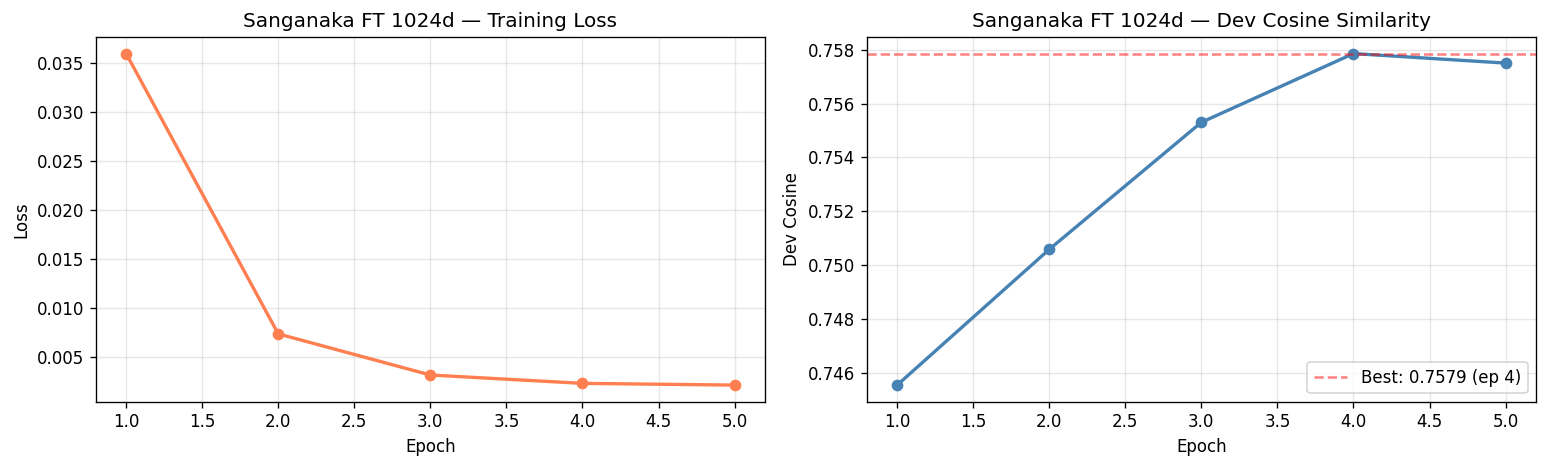

In [ ]:
# 4.2  Training Curves 

if sang_history:
    plot_training_curves(sang_history, "Sanganaka FT 1024d")
else:
    print("Loaded from checkpoint — no training curves to plot.")
    print("If you need curves, delete the checkpoint and retrain.")


## 5. Fine-Tune Qwen3-Embedding (Track B — Compact)

Fine-tune at 32-d, 64-d, 128.



  Qwen3-Embedding → 32-d


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  Model dtype: torch.bfloat16 → scaler=disabled


[Qwen-FT-32d] Epoch 1/5:   0%|          | 0/625 [00:00<?, ?it/s]

  Epoch 1  loss=0.4076  dev_cosine=0.8092
  ★ New best: 0.8092


...

  Epoch 3  loss=0.0277  dev_cosine=0.7726


[Qwen-FT-32d] Epoch 4/5:   0%|          | 0/625 [00:00<?, ?it/s]

  Epoch 4  loss=0.0189  dev_cosine=0.7727


[Qwen-FT-32d] Epoch 5/5:   0%|          | 0/625 [00:00<?, ?it/s]

  Epoch 5  loss=0.0152  dev_cosine=0.7728
Saved to Drive 
[M1-Qwen-FT-32d]  dim=32  avg_cosine=0.8092


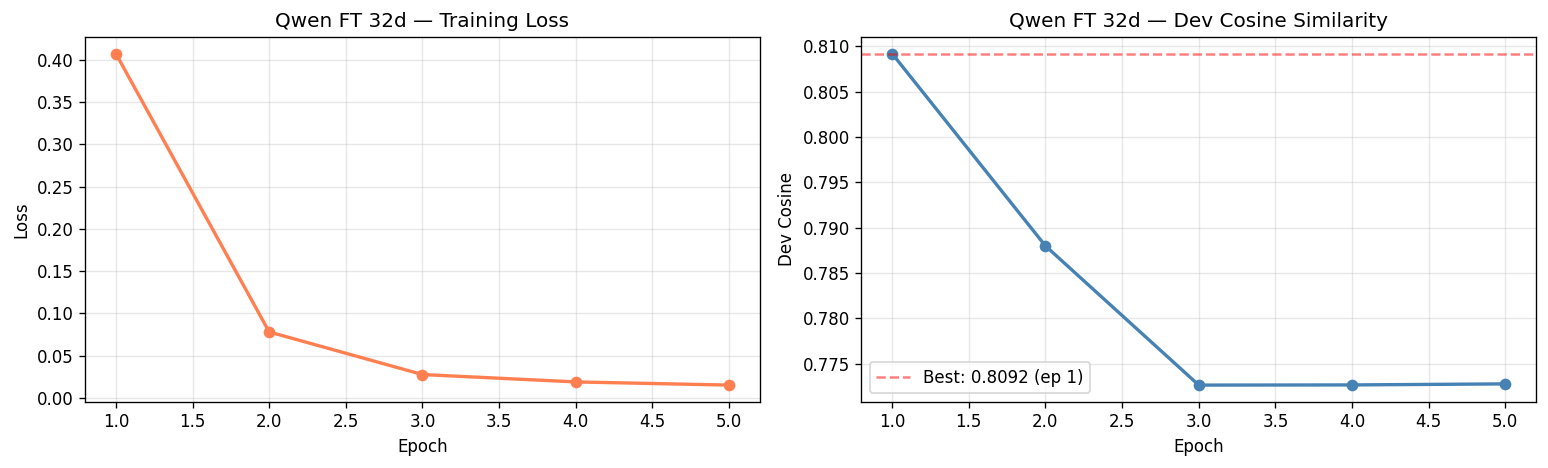


  Qwen3-Embedding → 64-d


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  Model dtype: torch.bfloat16 → scaler=disabled


[Qwen-FT-64d] Epoch 1/5:   0%|          | 0/625 [00:00<?, ?it/s]

  Epoch 1  loss=0.2822  dev_cosine=0.7609
  ★ New best: 0.7609


...

  Epoch 3  loss=0.0168  dev_cosine=0.7228


[Qwen-FT-64d] Epoch 4/5:   0%|          | 0/625 [00:00<?, ?it/s]

  Epoch 4  loss=0.0120  dev_cosine=0.7201


[Qwen-FT-64d] Epoch 5/5:   0%|          | 0/625 [00:00<?, ?it/s]

  Epoch 5  loss=0.0107  dev_cosine=0.7201
Saved to Drive 
[M1-Qwen-FT-64d]  dim=64  avg_cosine=0.7609


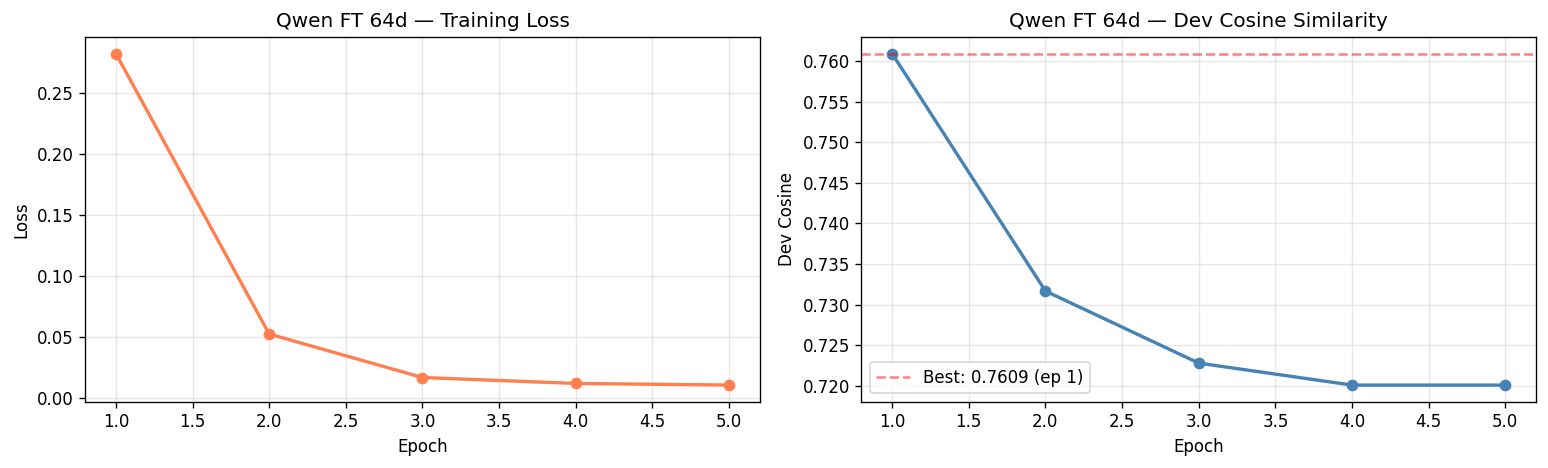


  Qwen3-Embedding → 128-d


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  Model dtype: torch.bfloat16 → scaler=disabled


[Qwen-FT-128d] Epoch 1/5:   0%|          | 0/625 [00:00<?, ?it/s]

  Epoch 1  loss=0.2107  dev_cosine=0.6901
  ★ New best: 0.6901


...

  Epoch 3  loss=0.0129  dev_cosine=0.6899


[Qwen-FT-128d] Epoch 4/5:   0%|          | 0/625 [00:00<?, ?it/s]

  Epoch 4  loss=0.0099  dev_cosine=0.6878


[Qwen-FT-128d] Epoch 5/5:   0%|          | 0/625 [00:00<?, ?it/s]

  Epoch 5  loss=0.0086  dev_cosine=0.6876
Saved to Drive 
[M1-Qwen-FT-128d]  dim=128  avg_cosine=0.6972


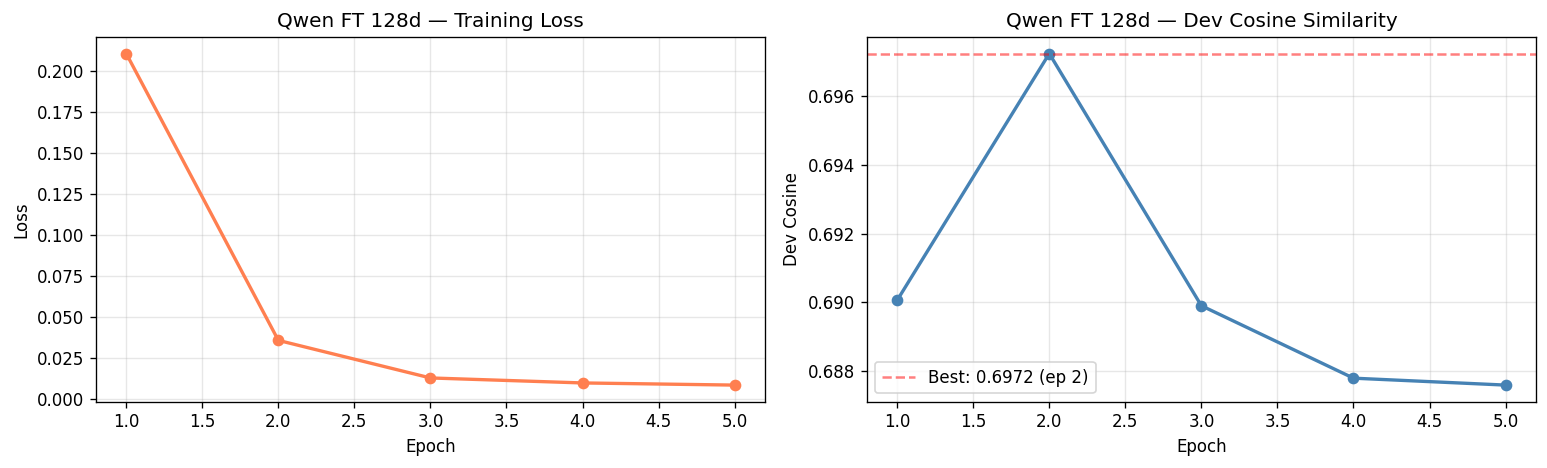


Qwen FT complete. Results: {32: 0.8092019557952881, 64: 0.7609254121780396, 128: 0.6972411274909973}


In [ ]:
# 5.1  Offload Sanganaka, train Qwen at each dim

sang_model_ft.cpu(); free_memory()

qwen_ft_models = {}
qwen_ft_results = {}
qwen_histories = {}

for dim in CFG["qwen_dims"]:
    ckpt_path = os.path.join(CFG["model_dir"], f"qwen_ft_{dim}d.pt")
    print(f"\n{'='*60}")
    print(f"  Qwen3-Embedding → {dim}-d")
    print(f"{'='*60}")

    qwen_ft = AutoModel.from_pretrained(CFG["qwen_name"]).to(DEVICE)
    qwen_ft, hist, _ = train_contrastive(
        qwen_ft, qwen_tokenizer, train_ds, dev_df,
        epochs=CFG["epochs"], lr=CFG["lr"], batch_size=CFG["batch_size"],
        max_len=CFG["max_seq_len"], pooling="lasttoken", output_dim=dim,
        is_qwen=True, label=f"Qwen-FT-{dim}d",
        grad_accum_steps=CFG["grad_accum_steps"], temperature=CFG["temperature"])
    torch.save(qwen_ft.state_dict(), ckpt_path)
    print(f"Saved to Drive ")

    # Dev eval
    en_dev = encode_sentences(dev_df["Sentence_en"].tolist(), qwen_tokenizer, qwen_ft,
                              output_dim=dim, pooling="lasttoken", is_qwen=True)
    sa_dev = encode_sentences(dev_df["Sentence_sa"].tolist(), qwen_tokenizer, qwen_ft,
                              output_dim=dim, pooling="lasttoken", is_qwen=True)
    res = eval_and_report(en_dev, sa_dev, f"M1-Qwen-FT-{dim}d")
    ALL_RESULTS.append(res)

    qwen_ft_models[dim] = ckpt_path
    qwen_ft_results[dim] = res["cosine"]
    qwen_histories[dim] = hist

    if hist:
        plot_training_curves(hist, f"Qwen FT {dim}d")

    del qwen_ft; free_memory()

print("\nQwen FT complete. Results:", qwen_ft_results)


## 5B. Fine-Tune Jina v5 (Track C — SOTA Compact)

Fine-tune `jina-embeddings-v5-text-small` at 32-d. 


In [ ]:
# Fine-Tune Jina v5 — 32-d  (or reload from Drive)

free_memory()

JINA_DIM = 32
JINA_CKPT = os.path.join(CFG["model_dir"], f"jina_ft_{JINA_DIM}d.pt")

jina_ft = AutoModel.from_pretrained(CFG["jina_name"], trust_remote_code=True).to(DEVICE)
jina_tokenizer = AutoTokenizer.from_pretrained(CFG["jina_name"], trust_remote_code=True)
jina_ft, jina_history, _ = train_contrastive(
    jina_ft, jina_tokenizer, train_ds, dev_df,
    epochs=CFG["epochs"], lr=CFG["lr"], batch_size=CFG["batch_size"],
    max_len=CFG["max_seq_len"], pooling="cls", output_dim=JINA_DIM,
    label=f"Jina-v5-FT-{JINA_DIM}d",
    grad_accum_steps=CFG["grad_accum_steps"], temperature=CFG["temperature"])
torch.save(jina_ft.state_dict(), JINA_CKPT)
print("Saved to Drive ")

# Dev eval
en_dev = encode_sentences(dev_df["Sentence_en"].tolist(), jina_tokenizer, jina_ft,
                          output_dim=JINA_DIM, pooling="cls")
sa_dev = encode_sentences(dev_df["Sentence_sa"].tolist(), jina_tokenizer, jina_ft,
                          output_dim=JINA_DIM, pooling="cls")
ALL_RESULTS.append(eval_and_report(en_dev, sa_dev, f"M3-Jina-FT-{JINA_DIM}d"))

jina_ft.cpu(); free_memory()


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

  Model dtype: torch.bfloat16 → scaler=disabled


[Jina-v5-FT-32d] Epoch 1/5:   0%|          | 0/625 [00:00<?, ?it/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


...

  Epoch 3  loss=2.6627  dev_cosine=0.9716


[Jina-v5-FT-32d] Epoch 4/5:   0%|          | 0/625 [00:00<?, ?it/s]

  Epoch 4  loss=2.6369  dev_cosine=0.9689


[Jina-v5-FT-32d] Epoch 5/5:   0%|          | 0/625 [00:00<?, ?it/s]

  Epoch 5  loss=2.6245  dev_cosine=0.9683
Saved to Drive 
[M3-Jina-FT-32d]  dim=32  avg_cosine=0.9878


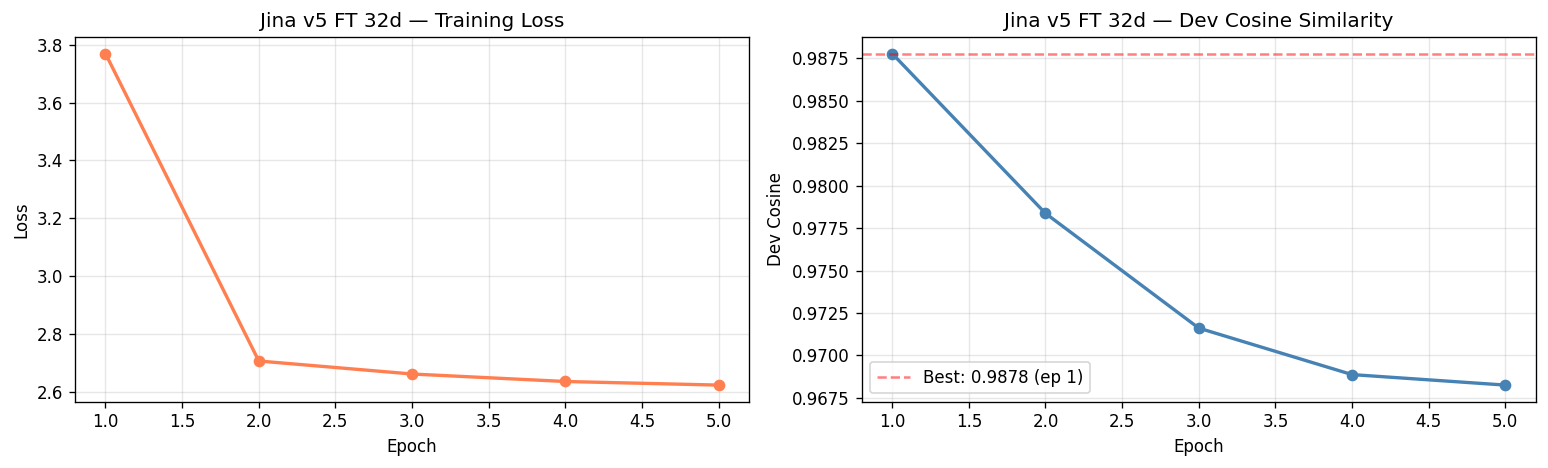

In [ ]:
if jina_history:
    plot_training_curves(jina_history, f"Jina v5 FT {JINA_DIM}d")
else:
    print("Loaded from checkpoint — no training curves to plot.")


## 6. Dimension-Reduction Ablations

**Track A:** Sanganaka 1024 → 128 / 64 / 32 (learned linear projection, encoder frozen)  
**Track B:** Qwen 128→32 projection vs native 32-d


In [ ]:
# 6.1  Projection infrastructure

class LearnedProjection(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.proj = nn.Linear(in_dim, out_dim)
    def forward(self, x):
        return F.normalize(self.proj(x), p=2, dim=-1)

class EmbeddingPairDataset(Dataset):
    def __init__(self, en_embs, sa_embs):
        self.en = torch.tensor(en_embs, dtype=torch.float32)
        self.sa = torch.tensor(sa_embs, dtype=torch.float32)
    def __len__(self): return len(self.en)
    def __getitem__(self, idx): return self.en[idx], self.sa[idx]

def train_projection(en_train, sa_train, en_dev, sa_dev,
                     in_dim, out_dim, epochs=10, lr=1e-3,
                     batch_size=256, temperature=0.05, label=""):
    proj = LearnedProjection(in_dim, out_dim).to(DEVICE)
    loader = DataLoader(EmbeddingPairDataset(en_train, sa_train),
                        batch_size=batch_size, shuffle=True, drop_last=True)
    criterion = SymmetricInfoNCE(temperature)
    optimizer = torch.optim.Adam(proj.parameters(), lr=lr)

    best_cos, best_state, history = -1.0, None, []

    for epoch in range(1, epochs + 1):
        proj.train()
        total_loss = 0
        for en_b, sa_b in loader:
            en_b, sa_b = en_b.to(DEVICE), sa_b.to(DEVICE)
            loss = criterion(proj(en_b), proj(sa_b))
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()

        proj.eval()
        with torch.no_grad():
            en_p = proj(torch.tensor(en_dev, dtype=torch.float32, device=DEVICE)).cpu().numpy()
            sa_p = proj(torch.tensor(sa_dev, dtype=torch.float32, device=DEVICE)).cpu().numpy()
        dev_cos, _ = eval_cosine_sklearn(en_p, sa_p)
        avg_loss = total_loss / len(loader)
        history.append({"epoch": epoch, "loss": avg_loss, "dev_cosine": dev_cos})

        if epoch == 1 or epoch % 3 == 0 or epoch == epochs:
            print(f"  [{label}] Ep {epoch}  loss={avg_loss:.4f}  dev_cos={dev_cos:.4f}")
        if dev_cos > best_cos:
            best_cos = dev_cos
            best_state = copy.deepcopy(proj.state_dict())

    proj.load_state_dict(best_state)
    return proj, best_cos, history


In [ ]:
# 6.2  Encode train+dev with Sanganaka FT (for projection training)

sang_model_ft.to(DEVICE)

print("Encoding train set with Sanganaka FT …")
sang_train_en = encode_sentences(train_df["Sentence_en"].tolist(), sang_tokenizer, sang_model_ft, batch_size=128, pooling="cls")
sang_train_sa = encode_sentences(train_df["Sentence_sa"].tolist(), sang_tokenizer, sang_model_ft, batch_size=128, pooling="cls")
print("Encoding dev set …")
sang_dev_en = encode_sentences(dev_df["Sentence_en"].tolist(), sang_tokenizer, sang_model_ft, batch_size=128, pooling="cls")
sang_dev_sa = encode_sentences(dev_df["Sentence_sa"].tolist(), sang_tokenizer, sang_model_ft, batch_size=128, pooling="cls")

sang_model_ft.cpu(); free_memory()
print(f"Done. Train: {sang_train_en.shape}, Dev: {sang_dev_en.shape}")


Encoding train set with Sanganaka FT …
Encoding dev set …
Done. Train: (10000, 1024), Dev: (1000, 1024)



--- Sang-Proj-128d ---
  [Sang-Proj-128d] Ep 1  loss=0.0601  dev_cos=0.7904
  [Sang-Proj-128d] Ep 3  loss=0.0170  dev_cos=0.7821
  [Sang-Proj-128d] Ep 6  loss=0.0125  dev_cos=0.7775
  [Sang-Proj-128d] Ep 9  loss=0.0111  dev_cos=0.7761
  [Sang-Proj-128d] Ep 10  loss=0.0102  dev_cos=0.7750
  → Sang-Proj-128d  dev_cosine=0.7904


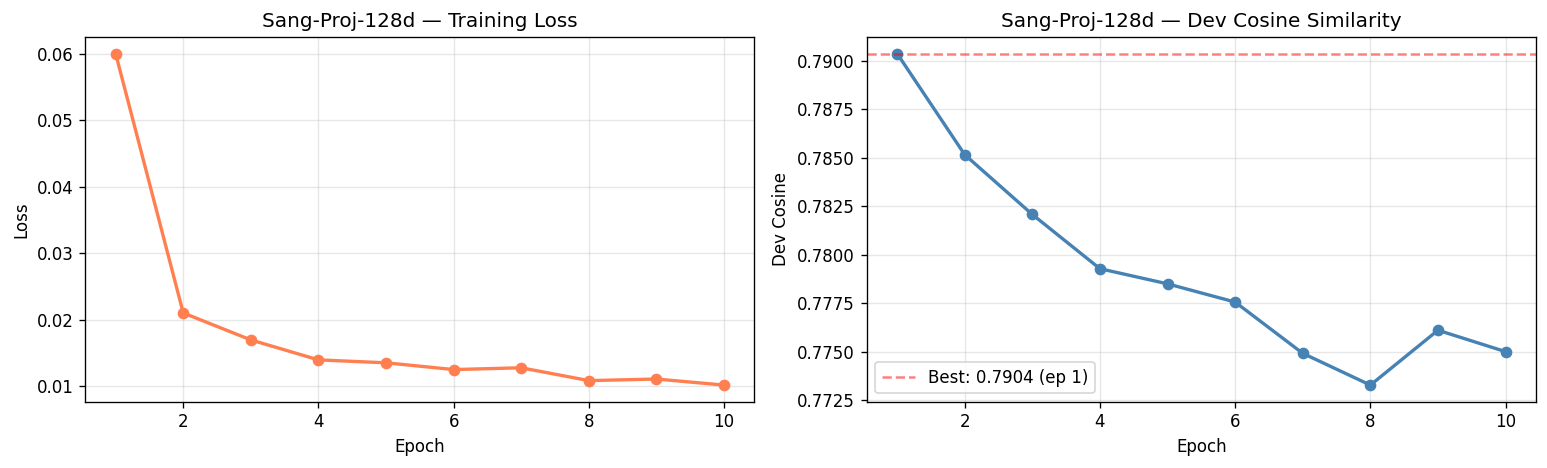


--- Sang-Proj-64d ---
  [Sang-Proj-64d] Ep 1  loss=0.0890  dev_cos=0.7963
  [Sang-Proj-64d] Ep 3  loss=0.0217  dev_cos=0.7888
  [Sang-Proj-64d] Ep 6  loss=0.0158  dev_cos=0.7861
  [Sang-Proj-64d] Ep 9  loss=0.0132  dev_cos=0.7828
  [Sang-Proj-64d] Ep 10  loss=0.0120  dev_cos=0.7819
  → Sang-Proj-64d  dev_cosine=0.7963


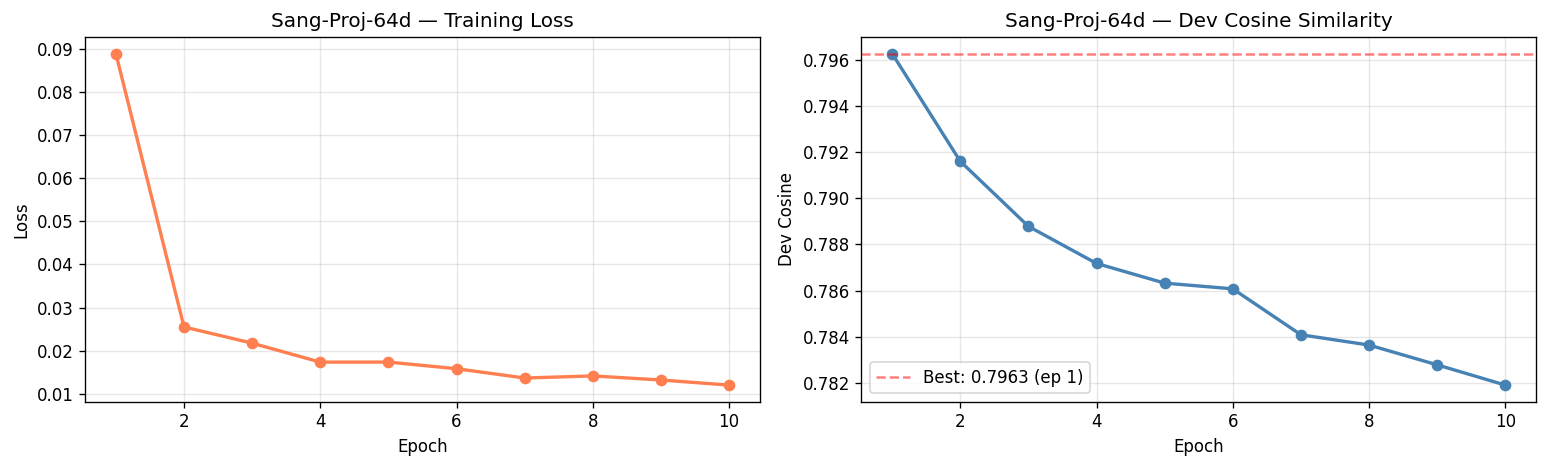


--- Sang-Proj-32d ---
  [Sang-Proj-32d] Ep 1  loss=0.1923  dev_cos=0.8127
  [Sang-Proj-32d] Ep 3  loss=0.0459  dev_cos=0.8083
  [Sang-Proj-32d] Ep 6  loss=0.0315  dev_cos=0.8076
  [Sang-Proj-32d] Ep 9  loss=0.0244  dev_cos=0.8084
  [Sang-Proj-32d] Ep 10  loss=0.0244  dev_cos=0.8081
  → Sang-Proj-32d  dev_cosine=0.8127


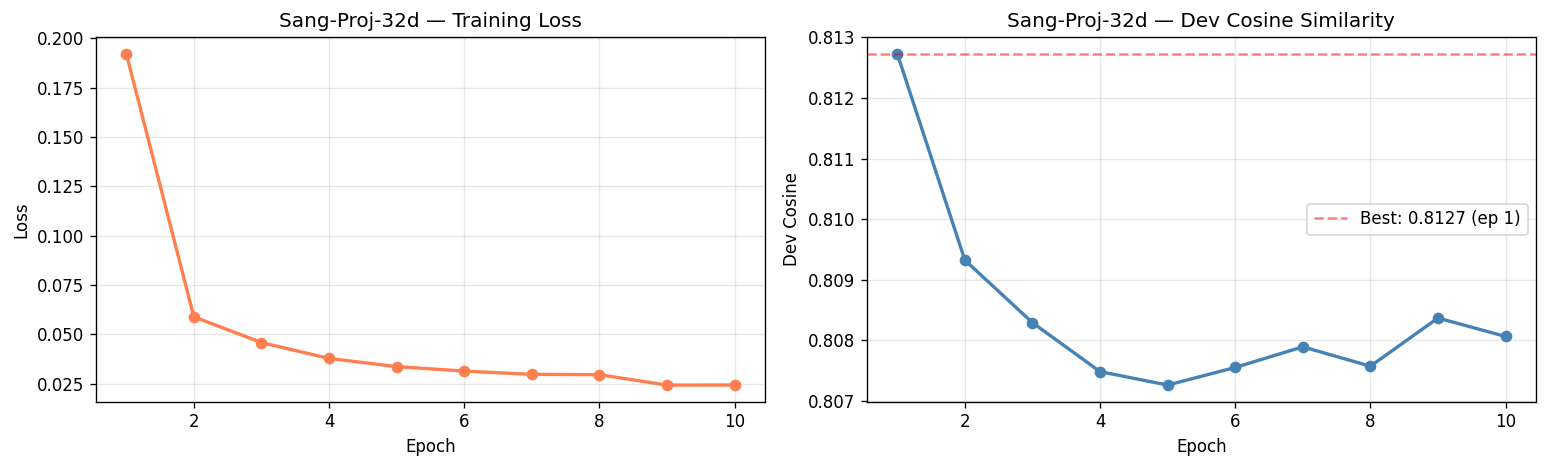

In [ ]:
# 6.3  Sanganaka Projections (A2, A3, A4) + IMMEDIATE PLOTS

proj_heads = {}

for target_dim in [128, 64, 32]:
    ckpt = os.path.join(CFG["model_dir"], f"sang_proj_{target_dim}d.pt")
    lbl = f"Sang-Proj-{target_dim}d"
    print(f"\n--- {lbl} ---")

    proj, dev_cos, hist = train_projection(
        sang_train_en, sang_train_sa, sang_dev_en, sang_dev_sa,
        1024, target_dim, epochs=CFG["proj_epochs"], lr=CFG["proj_lr"],
        batch_size=CFG["proj_batch_size"], temperature=CFG["temperature"], label=lbl)
    torch.save(proj.state_dict(), ckpt)

    proj_heads[target_dim] = proj
    res = {"label": f"A-{lbl}", "dim": target_dim, "cosine": dev_cos}
    ALL_RESULTS.append(res)
    print(f"  → {lbl}  dev_cosine={dev_cos:.4f}")

    if hist:
        plot_training_curves(hist, lbl)


Loading Qwen FT 128-d for projection …


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  [Qwen128→32-Proj] Ep 1  loss=0.7842  dev_cos=0.7436
  [Qwen128→32-Proj] Ep 3  loss=0.3266  dev_cos=0.7317
  [Qwen128→32-Proj] Ep 6  loss=0.2436  dev_cos=0.7314
  [Qwen128→32-Proj] Ep 9  loss=0.2102  dev_cos=0.7313
  [Qwen128→32-Proj] Ep 10  loss=0.2003  dev_cos=0.7313

Qwen 128→32 proj: 0.7436  vs  Qwen native 32-d: 0.8092019557952881


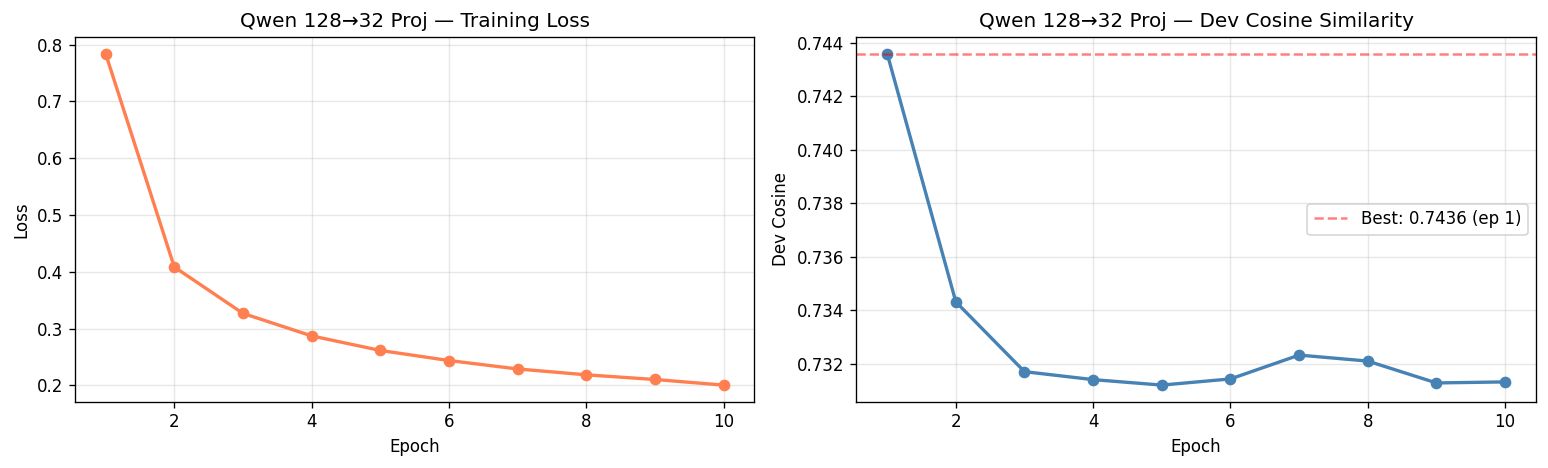

In [ ]:
# 6.4  Qwen 128→32 Projection Ablation

print("Loading Qwen FT 128-d for projection …")
qwen_128 = AutoModel.from_pretrained(CFG["qwen_name"]).to(DEVICE)
qwen_128.load_state_dict(torch.load(qwen_ft_models[128], map_location=DEVICE))
qwen_128.eval()

qwen128_train_en = encode_sentences(train_df["Sentence_en"].tolist(), qwen_tokenizer, qwen_128,
                                     batch_size=128, output_dim=128, pooling="lasttoken", is_qwen=True)
qwen128_train_sa = encode_sentences(train_df["Sentence_sa"].tolist(), qwen_tokenizer, qwen_128,
                                     batch_size=128, output_dim=128, pooling="lasttoken", is_qwen=True)
qwen128_dev_en = encode_sentences(dev_df["Sentence_en"].tolist(), qwen_tokenizer, qwen_128,
                                   batch_size=128, output_dim=128, pooling="lasttoken", is_qwen=True)
qwen128_dev_sa = encode_sentences(dev_df["Sentence_sa"].tolist(), qwen_tokenizer, qwen_128,
                                   batch_size=128, output_dim=128, pooling="lasttoken", is_qwen=True)
del qwen_128; free_memory()

ckpt = os.path.join(CFG["model_dir"], "qwen_proj_128to32.pt")
qwen_proj_32, qwen_proj_cos, qwen_proj_hist = train_projection(
    qwen128_train_en, qwen128_train_sa, qwen128_dev_en, qwen128_dev_sa,
    128, 32, epochs=CFG["proj_epochs"], lr=CFG["proj_lr"],
    batch_size=CFG["proj_batch_size"], temperature=CFG["temperature"],
    label="Qwen128→32-Proj")
torch.save(qwen_proj_32.state_dict(), ckpt)

ALL_RESULTS.append({"label": "B-Qwen128→32-Proj", "dim": 32, "cosine": qwen_proj_cos})
print(f"\nQwen 128→32 proj: {qwen_proj_cos:.4f}  vs  Qwen native 32-d: {qwen_ft_results.get(32, 'N/A')}")

if qwen_proj_hist:
    plot_training_curves(qwen_proj_hist, "Qwen 128→32 Proj")


## 7. Full Evaluation (Dev & Test)

All models evaluated on **test set** using `sklearn.metrics.pairwise.cosine_similarity`.


In [ ]:
# 7.1  Dev Results Summary

dev_results_df = pd.DataFrame(ALL_RESULTS)
min_dim = dev_results_df["dim"].min()
max_cos = dev_results_df["cosine"].max()
dev_results_df["marks_cosine"] = (dev_results_df["cosine"] / max_cos) * 0.6
dev_results_df["marks_dim"]    = (min_dim / dev_results_df["dim"]) * 0.4
dev_results_df["total_score"]  = dev_results_df["marks_cosine"] + dev_results_df["marks_dim"]
dev_results_df = dev_results_df.sort_values("total_score", ascending=False).reset_index(drop=True)

print("="*80)
print("  DEV SET RESULTS")
print("="*80)
print(dev_results_df.to_string(index=False))
dev_results_df.to_csv(os.path.join(CFG["output_dir"], "dev_results.csv"), index=False)


  DEV SET RESULTS
                label  dim   cosine  marks_cosine  marks_dim  total_score
       M3-Jina-FT-32d   32 0.985931      0.600000     0.4000     1.000000
      A-Sang-Proj-32d   32 0.812733      0.494598     0.4000     0.894598
       M1-Qwen-FT-32d   32 0.809202      0.492449     0.4000     0.892449
    B-Qwen128→32-Proj   32 0.743594      0.452523     0.4000     0.852523
       B3-Qwen-ZS-32d   32 0.655799      0.399094     0.4000     0.799094
       B4-Jina-ZS-32d   32 0.503239      0.306252     0.4000     0.706252
      A-Sang-Proj-64d   64 0.796265      0.484577     0.2000     0.684577
       M1-Qwen-FT-64d   64 0.760925      0.463070     0.2000     0.663070
     A-Sang-Proj-128d  128 0.790363      0.480985     0.1000     0.580985
       B3-Qwen-ZS-64d   64 0.616212      0.375003     0.2000     0.575003
      M1-Qwen-FT-128d  128 0.697241      0.424314     0.1000     0.524314
       B4-Jina-ZS-64d   64 0.520640      0.316841     0.2000     0.516841
M2-Sanganaka-FT-1024

In [ ]:
# 7.2  Test Evaluation — All Models

TEST_RESULTS = []

# --- Sanganaka FT + Projections ---
print("Loading Sanganaka FT …")
sang_ft = AutoModel.from_pretrained(CFG["sanganaka_name"]).to(DEVICE)
sang_ft.load_state_dict(torch.load(os.path.join(CFG["model_dir"], "sanganaka_ft_1024.pt"), map_location=DEVICE))
sang_ft.eval()

sang_test_en = encode_sentences(test_df["Sentence_en"].tolist(), sang_tokenizer, sang_ft, batch_size=64, pooling="cls")
sang_test_sa = encode_sentences(test_df["Sentence_sa"].tolist(), sang_tokenizer, sang_ft, batch_size=64, pooling="cls")
TEST_RESULTS.append(eval_and_report(sang_test_en, sang_test_sa, "TEST-Sanganaka-FT-1024d"))

for td in [128, 64, 32]:
    proj = LearnedProjection(1024, td).to(DEVICE)
    proj.load_state_dict(torch.load(os.path.join(CFG["model_dir"], f"sang_proj_{td}d.pt"), map_location=DEVICE))
    proj.eval()
    with torch.no_grad():
        en_p = proj(torch.tensor(sang_test_en, device=DEVICE)).cpu().numpy()
        sa_p = proj(torch.tensor(sang_test_sa, device=DEVICE)).cpu().numpy()
    TEST_RESULTS.append(eval_and_report(en_p, sa_p, f"TEST-Sang-Proj-{td}d"))
del sang_ft; free_memory()

# --- Qwen FT ---
for dim in CFG["qwen_dims"]:
    ckpt = os.path.join(CFG["model_dir"], f"qwen_ft_{dim}d.pt")
    if not os.path.exists(ckpt): continue
    m = AutoModel.from_pretrained(CFG["qwen_name"]).to(DEVICE)
    m.load_state_dict(torch.load(ckpt, map_location=DEVICE)); m.eval()
    en_t = encode_sentences(test_df["Sentence_en"].tolist(), qwen_tokenizer, m,
                            output_dim=dim, pooling="lasttoken", is_qwen=True)
    sa_t = encode_sentences(test_df["Sentence_sa"].tolist(), qwen_tokenizer, m,
                            output_dim=dim, pooling="lasttoken", is_qwen=True)
    TEST_RESULTS.append(eval_and_report(en_t, sa_t, f"TEST-Qwen-FT-{dim}d"))
    del m; free_memory()

# --- Qwen 128→32 Projection ---
ckpt128 = os.path.join(CFG["model_dir"], "qwen_ft_128d.pt")
ckpt_proj = os.path.join(CFG["model_dir"], "qwen_proj_128to32.pt")
if os.path.exists(ckpt128) and os.path.exists(ckpt_proj):
    m = AutoModel.from_pretrained(CFG["qwen_name"]).to(DEVICE)
    m.load_state_dict(torch.load(ckpt128, map_location=DEVICE)); m.eval()
    en_128 = encode_sentences(test_df["Sentence_en"].tolist(), qwen_tokenizer, m,
                              output_dim=128, pooling="lasttoken", is_qwen=True)
    sa_128 = encode_sentences(test_df["Sentence_sa"].tolist(), qwen_tokenizer, m,
                              output_dim=128, pooling="lasttoken", is_qwen=True)
    del m; free_memory()
    proj = LearnedProjection(128, 32).to(DEVICE)
    proj.load_state_dict(torch.load(ckpt_proj, map_location=DEVICE)); proj.eval()
    with torch.no_grad():
        en_p = proj(torch.tensor(en_128, device=DEVICE)).cpu().numpy()
        sa_p = proj(torch.tensor(sa_128, device=DEVICE)).cpu().numpy()
    TEST_RESULTS.append(eval_and_report(en_p, sa_p, "TEST-Qwen128→32-Proj"))


Loading Sanganaka FT …


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[TEST-Sanganaka-FT-1024d]  dim=1024  avg_cosine=0.7515
[TEST-Sang-Proj-128d]  dim=128  avg_cosine=0.7845
[TEST-Sang-Proj-64d]  dim=64  avg_cosine=0.7897
[TEST-Sang-Proj-32d]  dim=32  avg_cosine=0.8078


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[TEST-Qwen-FT-32d]  dim=32  avg_cosine=0.8059


...

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[TEST-Qwen128→32-Proj]  dim=32  avg_cosine=0.7439

Loading Jina v5 FT …


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

[TEST-Jina-FT-32d]  dim=32  avg_cosine=0.9862

  TEST SET RESULTS
                  label  dim   cosine  marks_cosine  marks_dim  total_score
       TEST-Jina-FT-32d   32 0.986224      0.600000     0.4000     1.000000
     TEST-Sang-Proj-32d   32 0.807794      0.491447     0.4000     0.891447
       TEST-Qwen-FT-32d   32 0.805923      0.490308     0.4000     0.890308
   TEST-Qwen128→32-Proj   32 0.743868      0.452556     0.4000     0.852556
     TEST-Sang-Proj-64d   64 0.789676      0.480424     0.2000     0.680424
       TEST-Qwen-FT-64d   64 0.756320      0.460131     0.2000     0.660131
    TEST-Sang-Proj-128d  128 0.784525      0.477291     0.1000     0.577291
      TEST-Qwen-FT-128d  128 0.694481      0.422509     0.1000     0.522509
TEST-Sanganaka-FT-1024d 1024 0.751467      0.457178     0.0125     0.469678

★ Best: TEST-Jina-FT-32d  dim=32  cosine=0.9862
Best model info saved ✓


## 8. t-SNE Visualization — 100 Test Pairs (Required)

Using the **best model** (Jina v5 FT 32-d).


In [ ]:
# 8.1  Generate embeddings with best model — Jina v5 FT 32-d

print("Loading best model: Jina v5 FT 32-d")
jina_best = AutoModel.from_pretrained(CFG["jina_name"], trust_remote_code=True).to(DEVICE)
jina_best.load_state_dict(torch.load(
    os.path.join(CFG["model_dir"], f"jina_ft_{JINA_DIM}d.pt"), map_location=DEVICE))
jina_best.eval()

en_test_embs = encode_sentences(test_df["Sentence_en"].tolist(), jina_tokenizer, jina_best,
                                 batch_size=64, max_len=CFG["max_seq_len"],
                                 output_dim=JINA_DIM, pooling="cls")
sa_test_embs = encode_sentences(test_df["Sentence_sa"].tolist(), jina_tokenizer, jina_best,
                                 batch_size=64, max_len=CFG["max_seq_len"],
                                 output_dim=JINA_DIM, pooling="cls")

test_cos, pair_cosines = eval_cosine_sklearn(en_test_embs, sa_test_embs)
print(f"Best model test cosine: {test_cos:.4f}, dim: {en_test_embs.shape[1]}")

del jina_best; free_memory()


Loading best model: Jina v5 FT 32-d


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Best model test cosine: 0.9862, dim: 32


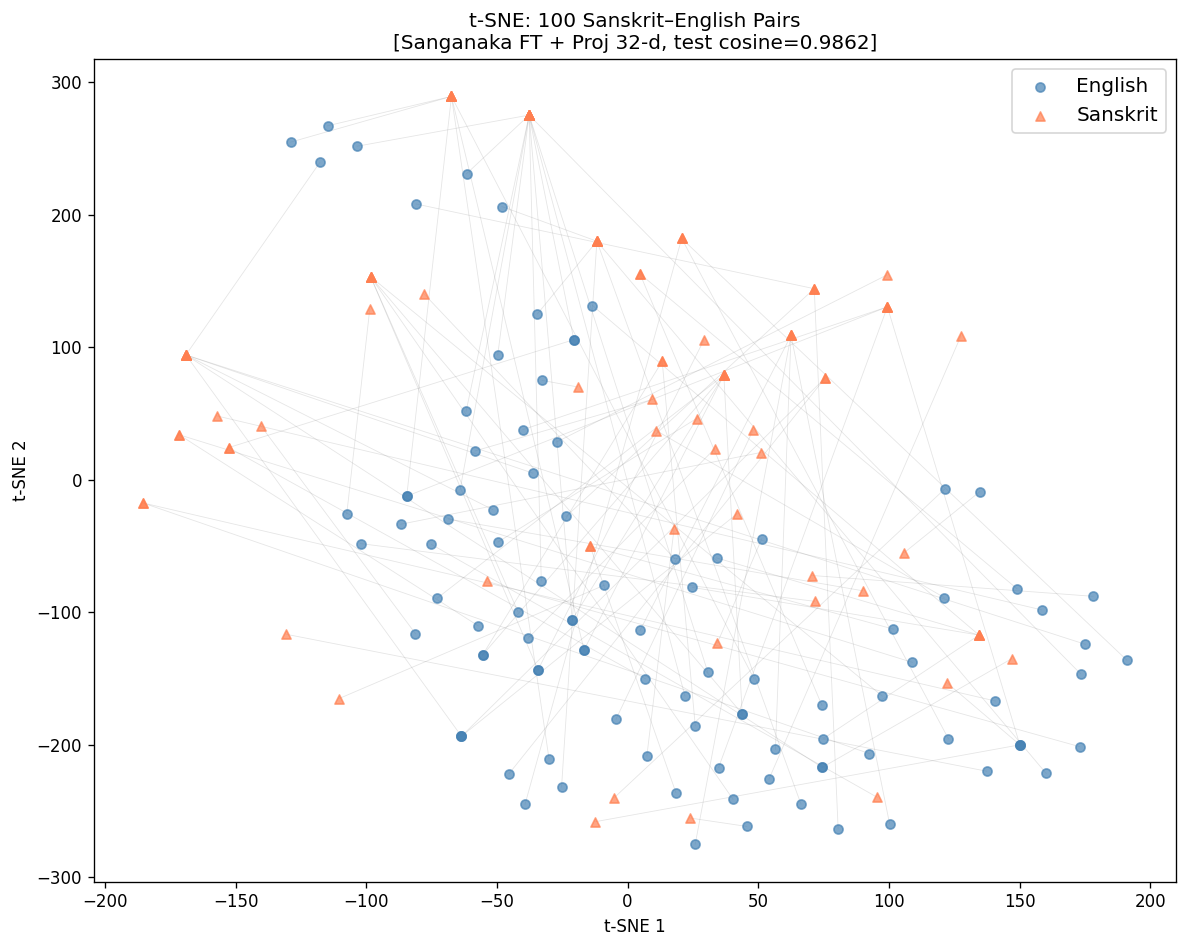

In [ ]:
# 8.2  t-SNE Plot

N_SAMPLES = 100
np.random.seed(CFG["seed"])
sample_idx = np.random.choice(len(en_test_embs), N_SAMPLES, replace=False)

en_sample = en_test_embs[sample_idx]
sa_sample = sa_test_embs[sample_idx]
combined = np.vstack([en_sample, sa_sample])

tsne = TSNE(n_components=2, random_state=CFG["seed"], perplexity=30, n_iter=1000)
coords = tsne.fit_transform(combined)
en_coords = coords[:N_SAMPLES]
sa_coords = coords[N_SAMPLES:]

fig, ax = plt.subplots(figsize=(10, 8))
for i in range(N_SAMPLES):
    ax.plot([en_coords[i, 0], sa_coords[i, 0]],
            [en_coords[i, 1], sa_coords[i, 1]], "grey", alpha=0.2, linewidth=0.5)
ax.scatter(en_coords[:, 0], en_coords[:, 1], c="steelblue", marker="o", s=30,
           label="English", alpha=0.7, zorder=5)
ax.scatter(sa_coords[:, 0], sa_coords[:, 1], c="coral", marker="^", s=30,
           label="Sanskrit", alpha=0.7, zorder=5)
ax.set_title(f"t-SNE: 100 Sanskrit–English Pairs\n[Sanganaka FT + Proj 32-d, test cosine={test_cos:.4f}]")
ax.legend(fontsize=12); ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "tsne_100pairs.png"), dpi=150, bbox_inches="tight")
plt.show()


## 9. Example Analysis — Best & Worst Pairs 

The assignment requires analysis of 5–10 examples. I show the 5 best and 5 worst aligned pairs.


In [ ]:
# 9.1  Best & Worst Pairs
sorted_idx = np.argsort(pair_cosines)

print("="*80)
print("  TOP 5 — Best Aligned Pairs")
print("="*80)
for rank, idx in enumerate(sorted_idx[-5:][::-1], 1):
    row = test_df.iloc[idx]
    print(f"\n#{rank}  cosine={pair_cosines[idx]:.4f}  (Source_id={row['Source_id']})")
    print(f"  EN: {row['Sentence_en'][:120]}")
    print(f"  SA: {row['Sentence_sa'][:120]}")

print("\n" + "="*80)
print("  BOTTOM 5 — Worst Aligned Pairs")
print("="*80)
for rank, idx in enumerate(sorted_idx[:5], 1):
    row = test_df.iloc[idx]
    print(f"\n#{rank}  cosine={pair_cosines[idx]:.4f}  (Source_id={row['Source_id']})")
    print(f"  EN: {row['Sentence_en'][:120]}")
    print(f"  SA: {row['Sentence_sa'][:120]}")


  TOP 5 — Best Aligned Pairs

#1  cosine=1.0000  (Source_id=214)
  EN: Total as 4000 and Actual cost as 0.00.
  SA: Total 4000 तथा Actual cost 0.00 इति च स्वयं गणयति ।

#2  cosine=1.0000  (Source_id=256)
  EN: Google Calendar.... and more.
  SA: Google Calendar.... एवमादयः।

#3  cosine=1.0000  (Source_id=991)
  EN: Blocks in Admin's Dashboard tutorial - explains how to add and delete blocks and
  SA: Blocks in Admin's Dashboard इति ट्युटोरियल् - blocks इत्यस्य संयोजनं निष्कासनं च कथमिति, तथैव

#4  cosine=1.0000  (Source_id=968)
  EN: ---Add the audio @02:32 from the tutorial nstallation of FrontAccounting on Window OS timing 08:10 to 08:30---
  SA: ---Add the audio @02:32 from the tutorial nstallation of FrontAccounting on Window OS timing 08:10 to 08:30---

#5  cosine=1.0000  (Source_id=692)
  EN: ii. We must take ___ daily to keep our skin clean.
  SA: ii. त्वच: स्वच्छतायै प्रत्यहं ..................... करणीयम्।

  BOTTOM 5 — Worst Aligned Pairs

#1  cosine=0.9227  (Source_id=785)
  

## 10. Additional Report Plots

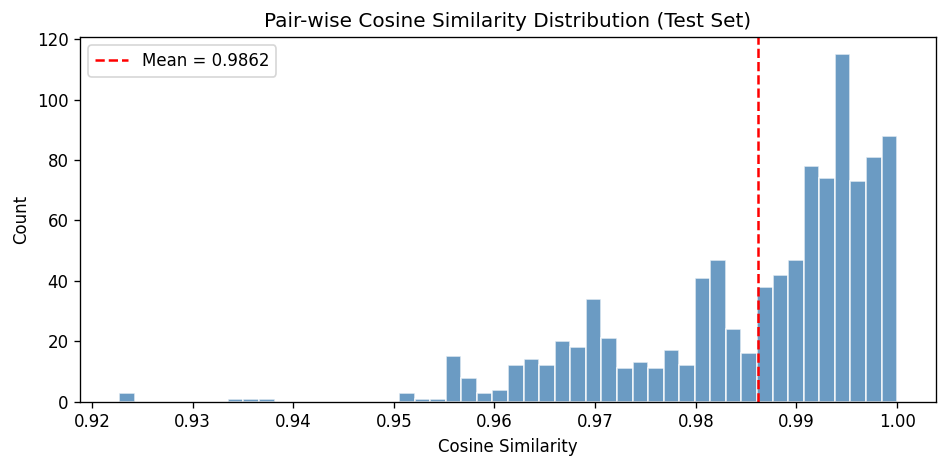

In [ ]:
# 10.1  Cosine Distribution Histogram (test set)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pair_cosines, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(pair_cosines.mean(), color="red", linestyle="--",
           label=f"Mean = {pair_cosines.mean():.4f}")
ax.set_xlabel("Cosine Similarity"); ax.set_ylabel("Count")
ax.set_title("Pair-wise Cosine Similarity Distribution (Test Set)")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "cosine_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()


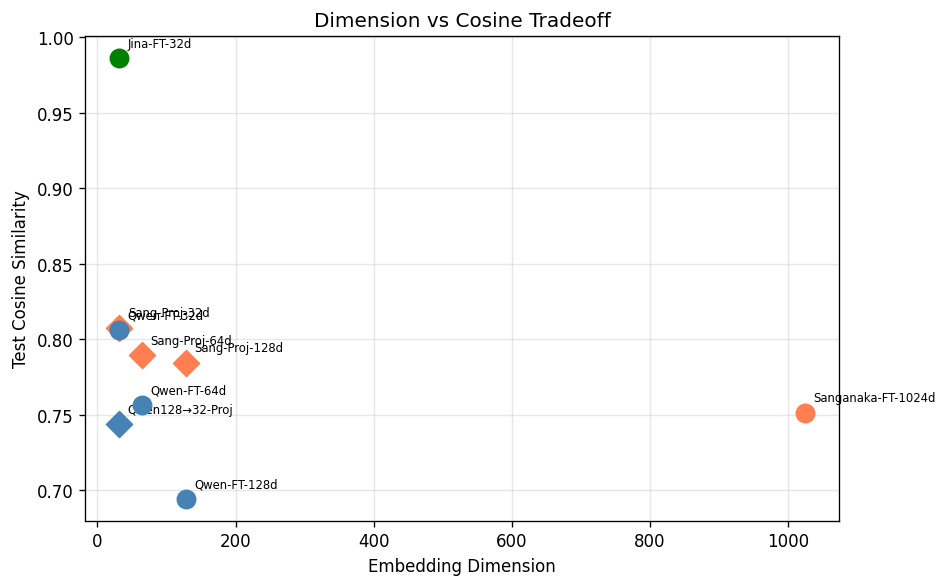

In [ ]:
# 10.2  Dimension vs Cosine Tradeoff (all test models)

fig, ax = plt.subplots(figsize=(8, 5))
for _, row in test_results_df.iterrows():
    color = "coral" if "Sang" in row["label"] else "steelblue" if "Qwen" in row["label"] else "green"
    marker = "D" if "Proj" in row["label"] else "o" if "FT" in row["label"] else "s"
    ax.scatter(row["dim"], row["cosine"], s=120, c=color, marker=marker, zorder=5)
    ax.annotate(row["label"].replace("TEST-",""), (row["dim"], row["cosine"]),
                fontsize=7, ha="left", va="bottom", xytext=(5, 5),
                textcoords="offset points")
ax.set_xlabel("Embedding Dimension"); ax.set_ylabel("Test Cosine Similarity")
ax.set_title("Dimension vs Cosine Tradeoff")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "dim_vs_cosine.png"), dpi=150, bbox_inches="tight")
plt.show()


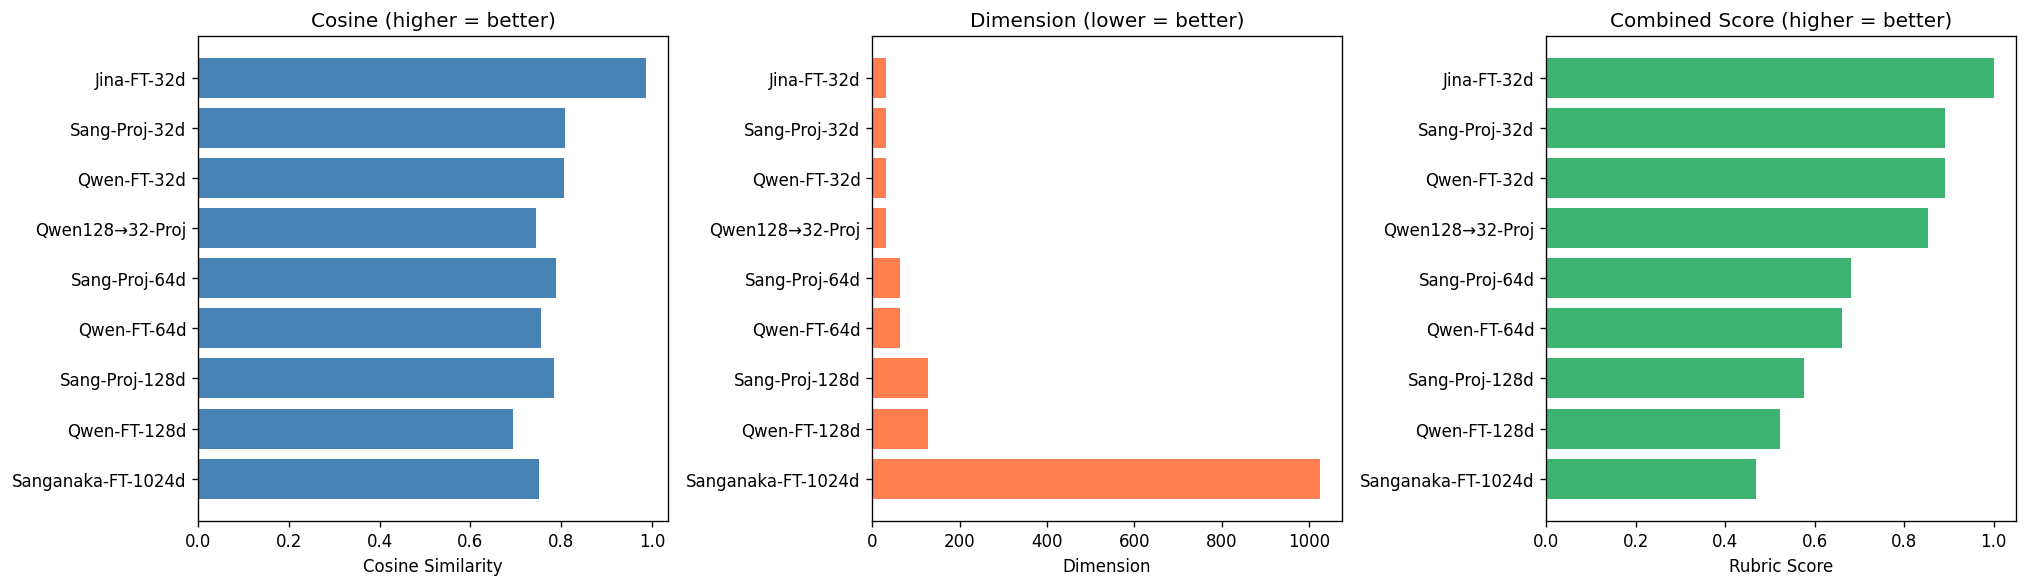

In [ ]:
# 10.3  Rubric Score Bar Chart

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

labels = [l.replace("TEST-","") for l in test_results_df["label"]]

ax = axes[0]
ax.barh(labels, test_results_df["cosine"], color="steelblue")
ax.set_xlabel("Cosine Similarity"); ax.set_title("Cosine (higher = better)"); ax.invert_yaxis()

ax = axes[1]
ax.barh(labels, test_results_df["dim"], color="coral")
ax.set_xlabel("Dimension"); ax.set_title("Dimension (lower = better)"); ax.invert_yaxis()

ax = axes[2]
ax.barh(labels, test_results_df["total_score"], color="mediumseagreen")
ax.set_xlabel("Rubric Score"); ax.set_title("Combined Score (higher = better)"); ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "rubric_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()


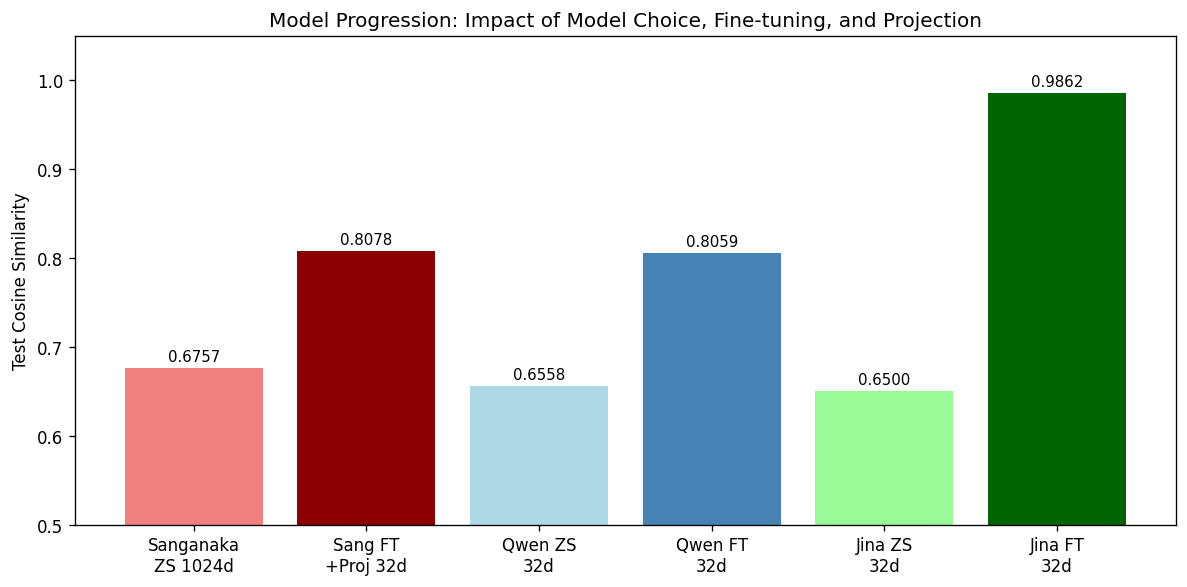

In [ ]:
# 10.4  Model Progression — Zero-shot → Fine-tuned (report narrative)

def safe_get_test_cos(pattern):
    matches = test_results_df[test_results_df["label"].str.contains(pattern)]
    return matches["cosine"].values[0] if len(matches) > 0 else 0

comparison_data = {
    "Sanganaka\nZS 1024d": 0.6757,
    "Sang FT\n+Proj 32d": safe_get_test_cos("Sang-Proj-32"),
    "Qwen ZS\n32d": 0.6558,
    "Qwen FT\n32d": safe_get_test_cos("Qwen-FT-32"),
    "Jina ZS\n32d": safe_get_test_cos("Jina-ZS-32") if safe_get_test_cos("Jina-ZS-32") > 0 else 0.65,
    "Jina FT\n32d": safe_get_test_cos("Jina-FT-32"),
}

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["lightcoral", "darkred", "lightblue", "steelblue", "palegreen", "darkgreen"]
bars = ax.bar(comparison_data.keys(), comparison_data.values(), color=colors)
ax.set_ylabel("Test Cosine Similarity")
ax.set_title("Model Progression: Impact of Model Choice, Fine-tuning, and Projection")
ax.set_ylim(0.5, 1.05)
for bar, val in zip(bars, comparison_data.values()):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f"{val:.4f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "model_progression.png"), dpi=150, bbox_inches="tight")
plt.show()


## 11. Final Submission Export

**Submission files:** `sa_embeddings.npy`, `en_embeddings.npy`  
**Format:** `(N, D)` NumPy arrays, row i = Source_id i  
**Best model:** Jina v5 FT 32-d (single model, no projection needed)


In [ ]:
# 11.1  Export .npy from best model
# en_test_embs and sa_test_embs were computed in Section 9

assert en_test_embs.shape[0] == len(test_df)
assert sa_test_embs.shape[0] == len(test_df)

np.save(os.path.join(CFG["output_dir"], "en_embeddings.npy"), en_test_embs.astype(np.float32))
np.save(os.path.join(CFG["output_dir"], "sa_embeddings.npy"), sa_test_embs.astype(np.float32))

# Verify
en_v = np.load(os.path.join(CFG["output_dir"], "en_embeddings.npy"))
sa_v = np.load(os.path.join(CFG["output_dir"], "sa_embeddings.npy"))
verify_cos, _ = eval_cosine_sklearn(en_v, sa_v)

print(f"en_embeddings.npy : shape={en_v.shape}, dtype={en_v.dtype}")
print(f"sa_embeddings.npy : shape={sa_v.shape}, dtype={sa_v.dtype}")
print(f"Verified cosine   : {verify_cos:.4f}")
print(f"\n✓ Saved to {CFG['output_dir']}/")


en_embeddings.npy : shape=(1000, 32), dtype=float32
sa_embeddings.npy : shape=(1000, 32), dtype=float32
Verified cosine   : 0.9862

✓ Saved to /content/drive/MyDrive/AIL7390_Assignment1/outputs/


## 12. Inference on New Test Data

Use this section at evaluation time when a private test set is released.
Place the new CSVs in `DATA_DIR` and run the cell below.

In [ ]:
# ============================================================
# 13.1  Inference — Private / New Test Set
# ============================================================
# Paths to new test CSVs (update filenames as needed)
NEW_EN_CSV = os.path.join(CFG["data_dir"], "private_test_en.csv")
NEW_SA_CSV = os.path.join(CFG["data_dir"], "private_test_sa.csv")

# ---- Load & align ----
df_en = pd.read_csv(NEW_EN_CSV, encoding="utf-8-sig")
df_sa = pd.read_csv(NEW_SA_CSV, encoding="utf-8-sig")
df_new = pd.merge(df_en, df_sa, on="Source_id", how="inner")
df_new["Source_id"] = df_new["Source_id"].astype(int)
df_new = df_new.sort_values("Source_id").reset_index(drop=True)
df_new["Sentence_en"] = df_new["Sentence_en"].astype(str).str.strip()
df_new["Sentence_sa"] = df_new["Sentence_sa"].astype(str).str.strip()
print(f"Loaded {len(df_new)} pairs")

# ---- Load best model (Jina v5 FT 32-d) ----
JINA_DIM = 32
JINA_CKPT = os.path.join(CFG["model_dir"], f"jina_ft_{JINA_DIM}d.pt")

jina_tok = AutoTokenizer.from_pretrained(CFG["jina_name"], trust_remote_code=True)
jina_mdl = AutoModel.from_pretrained(CFG["jina_name"], trust_remote_code=True).to(DEVICE)
jina_mdl.load_state_dict(torch.load(JINA_CKPT, map_location=DEVICE))
jina_mdl.eval()
print("Model loaded ✓")

# ---- Encode ----
en_embs = encode_sentences(
    df_new["Sentence_en"].tolist(), jina_tok, jina_mdl,
    batch_size=64, max_len=CFG["max_seq_len"],
    output_dim=JINA_DIM, pooling="cls")
sa_embs = encode_sentences(
    df_new["Sentence_sa"].tolist(), jina_tok, jina_mdl,
    batch_size=64, max_len=CFG["max_seq_len"],
    output_dim=JINA_DIM, pooling="cls")

# ---- Evaluate ----
avg_cos, pair_cos = eval_cosine_sklearn(en_embs, sa_embs)
print(f"Embedding dim : {en_embs.shape[1]}")
print(f"Num pairs     : {en_embs.shape[0]}")
print(f"Avg cosine    : {avg_cos:.4f}")

# ---- Save .npy ----
OUT_DIR = CFG["output_dir"]
np.save(os.path.join(OUT_DIR, "en_embeddings_private.npy"), en_embs.astype(np.float32))
np.save(os.path.join(OUT_DIR, "sa_embeddings_private.npy"), sa_embs.astype(np.float32))
print(f"\nSaved to {OUT_DIR}:")
print(f"  en_embeddings_private.npy : shape={en_embs.shape}")
print(f"  sa_embeddings_private.npy : shape={sa_embs.shape}")

# Cleanup
del jina_mdl; free_memory()
